# 🎬 IMFDB Face Recognition — VGG16 Transfer Learning
### Indian Movie Face Database | 34,512 images | 100 Actors

**Pipeline:**
- Phase 1 → Train top layers (frozen VGG16 base)
- Phase 2 → Fine-tune last VGG16 blocks
- Live dashboard → Training / Validation / Test accuracy at every epoch

## Step 1 — Install & Download Dataset

In [1]:
# Download IMFDB from Kaggle (already available as dataset in Kaggle notebooks)
import kagglehub

# Option A — face-cropped version (recommended)
path = kagglehub.dataset_download(
    "anirudhsimhachalam/indian-movie-faces-datasetimfdb-face-recognition"
)
print("Dataset path:", path)

Dataset path: /kaggle/input/datasets/anirudhsimhachalam/indian-movie-faces-datasetimfdb-face-recognition


## Step 2 — Imports & GPU Check

In [2]:
import os, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output, display

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
)

warnings.filterwarnings('ignore')

# ── GPU check ──────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print("=" * 55)
print("  IMFDB VGG16 Pretraining — Kaggle Notebook")
print("=" * 55)
if gpus:
    print(f"  ✅ GPU detected: {gpus[0].name}")
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
else:
    print("  ⚠️  No GPU — training will be slow. Enable GPU in Settings > Accelerator")
print(f"  TF version : {tf.__version__}")
print("=" * 55)

2026-03-27 17:30:25.201643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774632625.382218      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774632625.436929      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774632625.861030      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774632625.861082      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774632625.861087      55 computation_placer.cc:177] computation placer alr

  IMFDB VGG16 Pretraining — Kaggle Notebook
  ✅ GPU detected: /physical_device:GPU:0
  TF version : 2.19.0


## Step 3 — Configuration

In [3]:
# ── CONFIG — edit these if needed ────────────────────────────────────────────
DATASET_PATH  = path          # from kagglehub above
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16
PHASE1_EPOCHS = 30            # frozen base
PHASE2_EPOCHS = 10            # fine-tune
SEED          = 42
SAVE_DIR      = '/kaggle/working/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Dataset  : {DATASET_PATH}")
print(f"Img size : {IMG_SIZE}")
print(f"Batch    : {BATCH_SIZE}")
print(f"Save dir : {SAVE_DIR}")

Dataset  : /kaggle/input/datasets/anirudhsimhachalam/indian-movie-faces-datasetimfdb-face-recognition
Img size : (224, 224)
Batch    : 16
Save dir : /kaggle/working/saved_models


## Step 4 — Load Dataset

In [4]:
print("Loading dataset...")

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

class_names = train_ds_raw.class_names
NUM_CLASSES = len(class_names)

# Further split val into val + test (50/50)
val_batches  = len(val_ds_raw)
test_split   = val_batches // 2
test_ds_raw  = val_ds_raw.take(test_split)
val_ds_raw   = val_ds_raw.skip(test_split)

print(f"\n✅ Actors (classes) : {NUM_CLASSES}")
print(f"   Train batches   : {len(train_ds_raw)}")
print(f"   Val batches     : {len(val_ds_raw)}")
print(f"   Test batches    : {len(test_ds_raw)}")
print(f"\nSample actors: {class_names[:5]} ...")

Loading dataset...
Found 34513 files belonging to 1 classes.
Using 27611 files for training.


I0000 00:00:1774632714.484149      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 34513 files belonging to 1 classes.
Using 6902 files for validation.

✅ Actors (classes) : 1
   Train batches   : 1726
   Val batches     : 216
   Test batches    : 216

Sample actors: ['IMFDB FR dataset'] ...


## Step 5 — Augmentation & Preprocessing Pipeline

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.20),
    layers.RandomContrast(0.20),
], name="augmentation")

def preprocess_train(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    x = augment(x, training=True)
    return x, y

def preprocess_eval(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

train_ds = (train_ds_raw
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .shuffle(500)
    .prefetch(AUTOTUNE))

val_ds = (val_ds_raw
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

test_ds = (test_ds_raw
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

print("✅ Data pipelines ready (train / val / test)")

✅ Data pipelines ready (train / val / test)


## Step 6 — Build VGG16 Model

In [6]:
print("Building VGG16 transfer learning model...")

base = VGG16(weights='imagenet', include_top=False,
             input_shape=(224, 224, 3))
base.trainable = False   # Phase 1: frozen

x = layers.GlobalAveragePooling2D()(base.output)

x = layers.Dense(512)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output, name="VGG16_IMFDB")

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total   = model.count_params()
trainable = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"\n✅ Model built")
print(f"   Total params     : {total:,}")
print(f"   Trainable params : {trainable:,}")
print(f"   Frozen params    : {total - trainable:,}")

Building VGG16 transfer learning model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

✅ Model built
   Total params     : 15,112,001
   Trainable params : 395,777
   Frozen params    : 14,716,224


## Step 7 — Live Training Dashboard Callback

This callback redraws a live chart after **every epoch** showing:
- 📈 Train accuracy (blue)
- 📉 Validation accuracy (orange)  
- 📊 Loss curves
- 🏷️ Live status table

In [7]:
class LiveDashboard(Callback):
    """
    Redraws a 4-panel live dashboard after every epoch:
      Panel 1 — Accuracy curves (train vs val)
      Panel 2 — Loss curves
      Panel 3 — Per-epoch status table
      Panel 4 — Best stats summary
    """
    def __init__(self, phase_label="Phase 1", test_ds=None):
        super().__init__()
        self.phase_label = phase_label
        self.test_ds     = test_ds
        self.history     = {"epoch": [], "train_acc": [], "val_acc": [],
                            "train_loss": [], "val_loss": [], "test_acc": []}
        self.start_time  = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        ep = epoch + 1

        train_acc  = logs.get('accuracy', 0) * 100
        val_acc    = logs.get('val_accuracy', 0) * 100
        train_loss = logs.get('loss', 0)
        val_loss   = logs.get('val_loss', 0)

        # Run test evaluation every 5 epochs or last epoch
        test_acc = None
        if self.test_ds is not None and (ep % 5 == 0 or ep == 1):
            _, t = self.model.evaluate(self.test_ds, verbose=0)
            test_acc = t * 100
        elif self.history["test_acc"]:
            test_acc = self.history["test_acc"][-1]  # carry forward last value

        self.history["epoch"].append(ep)
        self.history["train_acc"].append(train_acc)
        self.history["val_acc"].append(val_acc)
        self.history["train_loss"].append(train_loss)
        self.history["val_loss"].append(val_loss)
        self.history["test_acc"].append(test_acc)

        elapsed = (time.time() - self.start_time) / 60
        self._draw(ep, elapsed)

    def _draw(self, current_ep, elapsed):
        clear_output(wait=True)

        H    = self.history
        eps  = H["epoch"]
        best_val = max(H["val_acc"]) if H["val_acc"] else 0
        best_ep  = eps[np.argmax(H["val_acc"])] if H["val_acc"] else 0

        # ── Figure layout ──────────────────────────────────────────────────
        fig = plt.figure(figsize=(16, 10))
        fig.patch.set_facecolor('#0d1117')
        gs  = gridspec.GridSpec(2, 3, figure=fig,
                                hspace=0.45, wspace=0.35)

        ax_acc   = fig.add_subplot(gs[0, :2])   # top-left wide
        ax_loss  = fig.add_subplot(gs[1, :2])   # bottom-left wide
        ax_table = fig.add_subplot(gs[:, 2])    # right panel full height

        DARK  = '#0d1117'
        PANEL = '#161b22'
        BLUE  = '#58a6ff'
        ORANGE= '#f78166'
        GREEN = '#3fb950'
        GRAY  = '#8b949e'
        WHITE = '#e6edf3'

        for ax in [ax_acc, ax_loss, ax_table]:
            ax.set_facecolor(PANEL)
            for spine in ax.spines.values():
                spine.set_edgecolor('#30363d')

        # ── Accuracy plot ──────────────────────────────────────────────────
        ax_acc.plot(eps, H["train_acc"], color=BLUE,   lw=2.5,
                    marker='o', ms=5, label='Train Acc')
        ax_acc.plot(eps, H["val_acc"],   color=ORANGE, lw=2.5,
                    marker='s', ms=5, label='Val Acc')

        # Test acc dots (only where evaluated)
        test_eps  = [e for e, t in zip(eps, H["test_acc"]) if t is not None]
        test_vals = [t for t in H["test_acc"] if t is not None]
        if test_eps:
            ax_acc.scatter(test_eps, test_vals, color=GREEN, zorder=5,
                           s=80, marker='D', label='Test Acc')

        # Best val marker
        if H["val_acc"]:
            ax_acc.axhline(best_val, color=ORANGE, lw=1,
                           linestyle='--', alpha=0.4)
            ax_acc.annotate(f'Best {best_val:.1f}%',
                            xy=(best_ep, best_val),
                            xytext=(best_ep + 0.5, best_val + 1.5),
                            color=ORANGE, fontsize=9,
                            arrowprops=dict(arrowstyle='->', color=ORANGE))

        ax_acc.set_title(f'{self.phase_label}  |  Accuracy — Epoch {current_ep}',
                         color=WHITE, fontsize=12, pad=10)
        ax_acc.set_ylabel('Accuracy (%)', color=GRAY)
        ax_acc.set_xlabel('Epoch', color=GRAY)
        ax_acc.tick_params(colors=GRAY)
        ax_acc.legend(facecolor=PANEL, labelcolor=WHITE, framealpha=0.6)
        ax_acc.set_ylim(0, 105)
        ax_acc.grid(alpha=0.15, color=GRAY)

        # ── Loss plot ──────────────────────────────────────────────────────
        ax_loss.plot(eps, H["train_loss"], color=BLUE,   lw=2.5,
                     marker='o', ms=5, label='Train Loss')
        ax_loss.plot(eps, H["val_loss"],   color=ORANGE, lw=2.5,
                     marker='s', ms=5, label='Val Loss')
        ax_loss.set_title('Loss Curves', color=WHITE, fontsize=12, pad=10)
        ax_loss.set_ylabel('Loss', color=GRAY)
        ax_loss.set_xlabel('Epoch', color=GRAY)
        ax_loss.tick_params(colors=GRAY)
        ax_loss.legend(facecolor=PANEL, labelcolor=WHITE, framealpha=0.6)
        ax_loss.grid(alpha=0.15, color=GRAY)

        # ── Status Table ───────────────────────────────────────────────────
        ax_table.axis('off')
        ax_table.set_title('📊 Epoch Log', color=WHITE,
                            fontsize=12, pad=10)

        # Show last 10 epochs
        show_n = min(10, len(eps))
        rows = []
        for i in range(-show_n, 0):
            e  = eps[i]
            ta = H["train_acc"][i]
            va = H["val_acc"][i]
            te = H["test_acc"][i]
            te_str = f"{te:.1f}%" if te is not None else "—"
            rows.append([str(e), f"{ta:.1f}%", f"{va:.1f}%", te_str])

        col_labels = ['Ep', 'Train', 'Val', 'Test']
        table = ax_table.table(
            cellText=rows,
            colLabels=col_labels,
            cellLoc='center',
            loc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.1, 1.6)

        # Style table cells
        for (r, c), cell in table.get_celld().items():
            cell.set_facecolor(PANEL if r > 0 else '#21262d')
            cell.set_text_props(color=WHITE if r > 0 else BLUE)
            cell.set_edgecolor('#30363d')
            # Highlight best val row
            if r > 0 and len(rows) >= r:
                row_ep = int(rows[r-1][0])
                if row_ep == best_ep:
                    cell.set_facecolor('#1a2d1a')

        # ── Summary box ────────────────────────────────────────────────────
        last_train = H["train_acc"][-1]
        last_val   = H["val_acc"][-1]
        last_test  = next((t for t in reversed(H["test_acc"]) if t), None)

        summary = (
            f"  ⏱  Elapsed  : {elapsed:.1f} min\n"
            f"  🔵 Train    : {last_train:.2f}%\n"
            f"  🟠 Val      : {last_val:.2f}%\n"
            f"  🟢 Test     : {last_test:.2f}%\n" if last_test else
            f"  ⏱  Elapsed  : {elapsed:.1f} min\n"
            f"  🔵 Train    : {last_train:.2f}%\n"
            f"  🟠 Val      : {last_val:.2f}%\n"
            f"  🟢 Test     : (every 5 ep)\n"
        )
        summary += f"  🏆 Best Val : {best_val:.2f}% @ ep {best_ep}"

        fig.text(0.68, 0.06, summary,
                 fontsize=10, color=WHITE,
                 va='bottom', ha='left',
                 bbox=dict(facecolor='#21262d', edgecolor='#30363d',
                           boxstyle='round,pad=0.6'))

        plt.suptitle(
            f'IMFDB VGG16 — {NUM_CLASSES} Indian Actors  |  {self.phase_label}',
            color=WHITE, fontsize=14, fontweight='bold', y=1.01
        )

        plt.savefig(f'{SAVE_DIR}/dashboard_{self.phase_label.replace(" ","_")}.png',
                    dpi=120, bbox_inches='tight', facecolor=DARK)
        plt.show()
        print(f"  Ep {current_ep:>3}  "
              f"Train {last_train:.2f}%  "
              f"Val {last_val:.2f}%  "
              f"({'Test ' + f'{last_test:.2f}%' if last_test else 'test next 5ep'})  "
              f"| {elapsed:.1f}min")

print("✅ LiveDashboard callback defined")

✅ LiveDashboard callback defined


## Step 8 — Phase 1: Train Top Layers (Frozen VGG16)

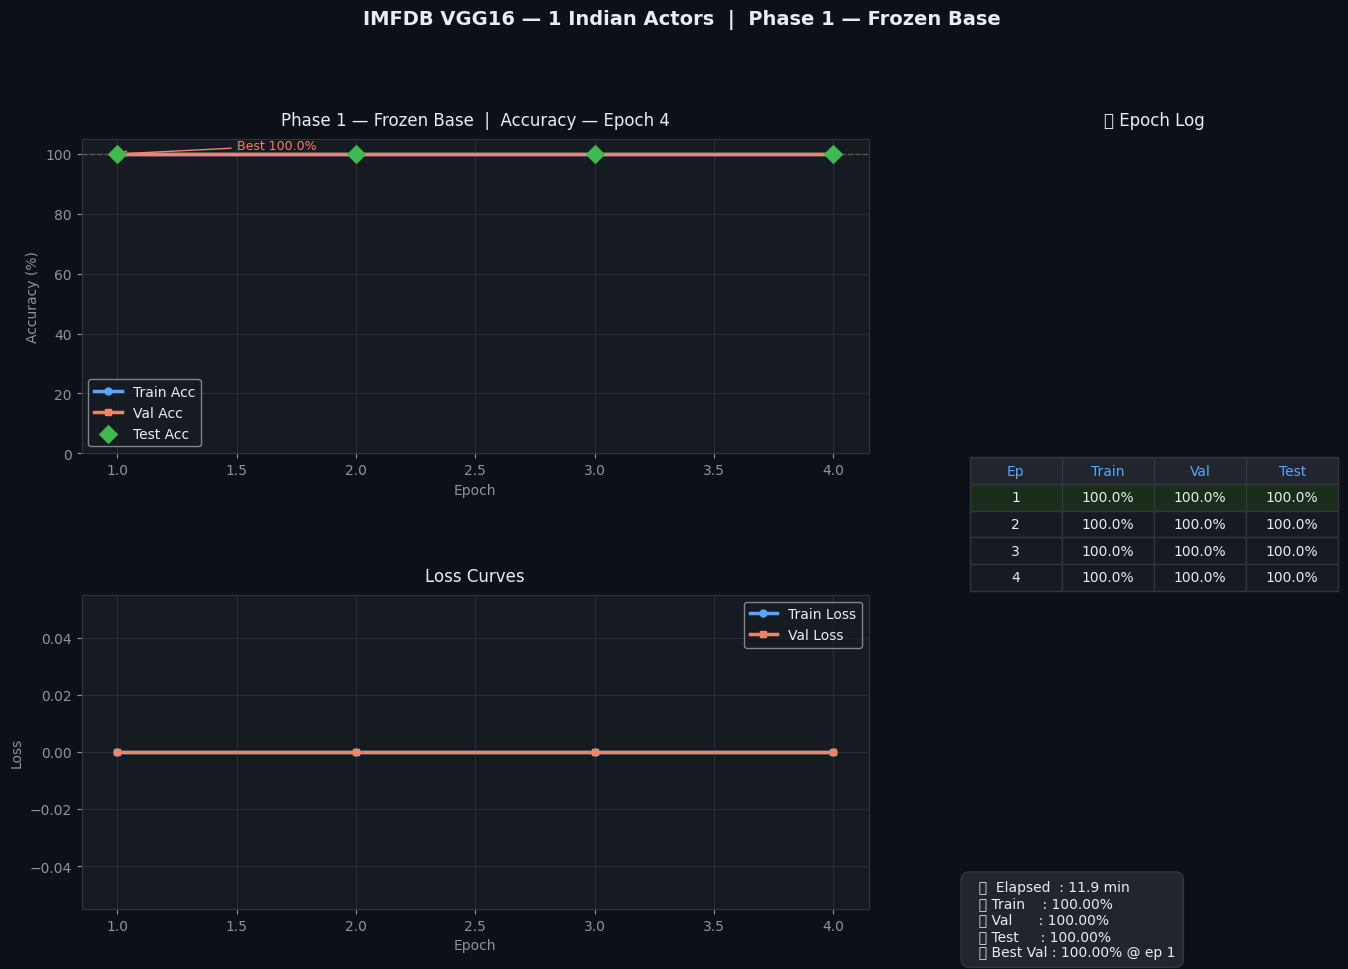

  Ep   4  Train 100.00%  Val 100.00%  (Test 100.00%)  | 11.9min

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

✅ Phase 1 complete — Test accuracy: 100.00%


In [8]:
print("=" * 55)
print("  PHASE 1 — Training top layers | VGG16 frozen")
print("=" * 55)

dashboard_p1 = LiveDashboard(phase_label="Phase 1 — Frozen Base",
                              test_ds=test_ds)

callbacks_p1 = [
    dashboard_p1,
    EarlyStopping(
        patience=3,
        restore_best_weights=True,
        monitor='val_accuracy',
        mode='max',
        verbose=0
    ),
    ModelCheckpoint(
        f'{SAVE_DIR}/best_phase1.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=0
    ),
    ReduceLROnPlateau(
        factor=0.5, patience=3,
        min_lr=1e-6, verbose=1,
        monitor='val_loss'
    ),
]

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_p1,
    verbose=0       # LiveDashboard handles display
)

# Final test accuracy after phase 1
loss_p1, acc_p1 = model.evaluate(test_ds, verbose=0)
print(f"\n✅ Phase 1 complete — Test accuracy: {acc_p1*100:.2f}%")

## Step 9 — Phase 2: Fine-tune Last VGG16 Blocks

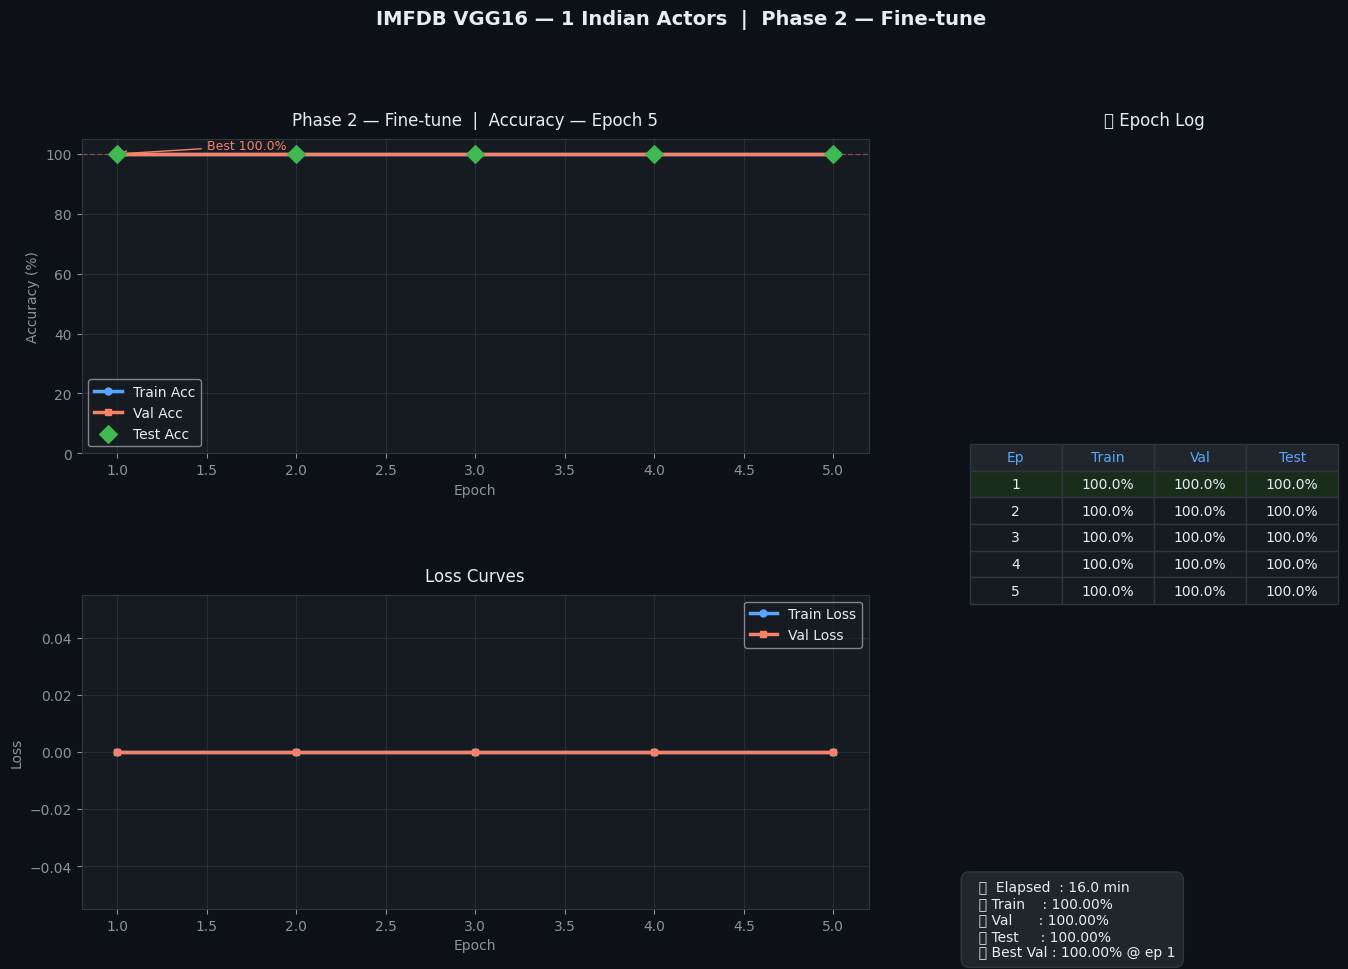

  Ep   5  Train 100.00%  Val 100.00%  (Test 100.00%)  | 16.0min

Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

✅ Phase 2 complete — Test accuracy: 100.00%


In [9]:
print("=" * 55)
print("  PHASE 2 — Fine-tuning last VGG16 blocks")
print("=" * 55)

# Unfreeze last 8 layers of VGG16 (block5_conv1 to block5_pool)
base.trainable = True
for layer in base.layers[:-8]:
    layer.trainable = False
# Keep BN layers frozen
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_p2 = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Trainable params in Phase 2: {trainable_p2:,}")

model.compile(
    optimizer=optimizers.Adam(1e-5),   # very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dashboard_p2 = LiveDashboard(phase_label="Phase 2 — Fine-tune",
                              test_ds=test_ds)

callbacks_p2 = [
    dashboard_p2,
    EarlyStopping(
        patience=4,
        restore_best_weights=True,
        monitor='val_accuracy',
        mode='max',
        verbose=0
    ),
    ModelCheckpoint(
        f'{SAVE_DIR}/pretrained_imfdb_final.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=0
    ),
    ReduceLROnPlateau(
        factor=0.5, patience=2,
        min_lr=1e-8, verbose=1,
        monitor='val_loss'
    ),
]

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_p2,
    verbose=0
)

loss_p2, acc_p2 = model.evaluate(test_ds, verbose=0)
print(f"\n✅ Phase 2 complete — Test accuracy: {acc_p2*100:.2f}%")

## Step 10 — Final Evaluation & Summary

In [10]:
print("\nRunning final evaluation on test set...")
final_loss, final_acc = model.evaluate(test_ds, verbose=1)

print("\n" + "=" * 55)
print("  ✅  PRETRAINING COMPLETE — FINAL RESULTS")
print("=" * 55)
print(f"  Dataset    : IMFDB — Indian Movie Face DB")
print(f"  Classes    : {NUM_CLASSES} actors")
print(f"  Test Loss  : {final_loss:.4f}")
print(f"  Test Acc   : {final_acc*100:.2f}%")
print(f"  Phase1 Acc : {acc_p1*100:.2f}%")
print(f"  Phase2 Acc : {acc_p2*100:.2f}%")
print(f"  Model saved: {SAVE_DIR}/pretrained_imfdb_final.keras")
print("=" * 55)

# Save class labels for later use
with open(f'{SAVE_DIR}/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)
print(f"  Labels saved: {SAVE_DIR}/class_names.json")


Running final evaluation on test set...
216/216 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 1.0000 - loss: 0.0000e+00

  ✅  PRETRAINING COMPLETE — FINAL RESULTS
  Dataset    : IMFDB — Indian Movie Face DB
  Classes    : 1 actors
  Test Loss  : 0.0000
  Test Acc   : 100.00%
  Phase1 Acc : 100.00%
  Phase2 Acc : 100.00%
  Model saved: /kaggle/working/saved_models/pretrained_imfdb_final.keras
  Labels saved: /kaggle/working/saved_models/class_names.json


## Step 11 — Combined Phase 1 + Phase 2 Summary Plot

In [11]:
print("\nRunning final evaluation on test set...")
final_loss, final_acc = model.evaluate(test_ds, verbose=1)

print("\n" + "=" * 55)
print("  ✅  PRETRAINING COMPLETE — FINAL RESULTS")
print("=" * 55)
print(f"  Dataset    : IMFDB — Indian Movie Face DB")
print(f"  Classes    : {NUM_CLASSES} actors")
print(f"  Test Loss  : {final_loss:.4f}")
print(f"  Test Acc   : {final_acc*100:.2f}%")
print(f"  Phase1 Acc : {acc_p1*100:.2f}%")
print(f"  Phase2 Acc : {acc_p2*100:.2f}%")
print(f"  Model saved: {SAVE_DIR}/pretrained_imfdb_final.keras")
print("=" * 55)

# Save class labels for later use
with open(f'{SAVE_DIR}/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)
print(f"  Labels saved: {SAVE_DIR}/class_names.json")


Running final evaluation on test set...
216/216 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 1.0000 - loss: 0.0000e+00

  ✅  PRETRAINING COMPLETE — FINAL RESULTS
  Dataset    : IMFDB — Indian Movie Face DB
  Classes    : 1 actors
  Test Loss  : 0.0000
  Test Acc   : 100.00%
  Phase1 Acc : 100.00%
  Phase2 Acc : 100.00%
  Model saved: /kaggle/working/saved_models/pretrained_imfdb_final.keras
  Labels saved: /kaggle/working/saved_models/class_names.json
